In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.rate_constants import Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter
from diffPLOG2TROE.optimization import LossType

import matplotlib.pyplot as plt

In [3]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
    # "A": {"optimize": False, "value": 5.28683e-01},
    # "T3": {"optimize": False, "value": 7.05782e+02},
    # "T1": {"optimize": False, "value": 7.08866e+02},
    # "T2": {"optimize": False, "value": 3.33264e+03},
    # LOW / 		7.81103e+33 -5.02168 5.34730e+03 /
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config,
    loss_name="log",
    log_name="nlopt-refit-logloss-lbfgs.log"
)

optax_options = {
    "algorithm": "DIRECT",
    "max_eval": 10000,
    "ftol_rel": 1e-10,
    "xtol_rel": 1e-10,
    "steps_file": 100,
    "patience": 1000,
    "ftol": 1e-10,
    "learning_rate": 6e-2
}

initial_troe = refitter.fit(nlopt_options=optax_options)
print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.1, 100)
 Loss function: log

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Starting optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 9.954e+29, -3.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03

  Step 0: loss = 9.240451e-01
  Step 100: loss = 5.892003e+00
  Step 200: loss = 5.207483e+00
  Step 300: loss = 9.241290e-01
  Step 400: loss = 9.127736e-01
  Step 500: loss = 4.872459e+00
 

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW / 		5.33640e+29 -3.95214 2.14865e+03 /
 TROE / 1.23457e-01 1.23457e+04 5.00000e+29 5.00000e+29 /


Minimum error: 0.636586248412088
Maximum error: 2.419268112147266
Average error: 0.331290686987127


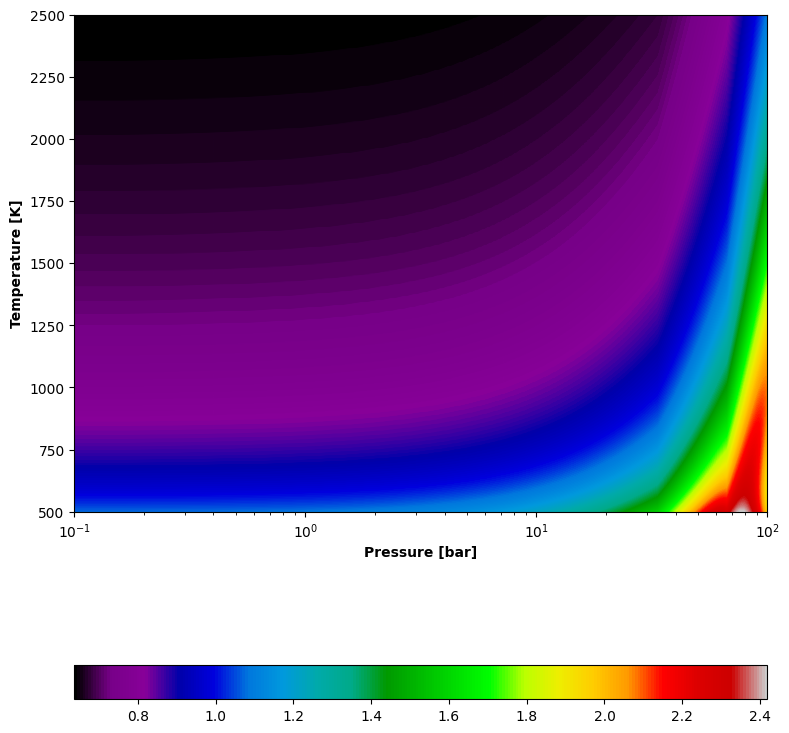

In [4]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_falloff_map.T / k_plog_map.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="nipy_spectral"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()

In [ ]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
    "A":      {"optimize": True,  "value": 4.62127e-01},
    "T3":     {"optimize": True, "value": 1.00000e+01},
    "T1":     {"optimize": True, "value": 2.26431e+03},
    "T2":     {"optimize": True, "value": 7.23206e+03},
    "A_low":  {"optimize": True,  "value": 5.86259e+29},
    "n_low":  {"optimize": True,  "value": -3.84993},
    "E_low":  {"optimize": True,  "value": 2.70542e+03},
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config,
    loss_name="log",
    log_name="nlopt-refit-logloss-isres.log"
)

nlopt_options = {
    "algorithm": "ISRES",
    "max_eval": 100000,
    "ftol_rel": 1e-15,
    "xtol_rel": 1e-15,
    "steps_file": 1000
}

initial_troe = refitter.fit(nlopt_options=nlopt_options)
print(FallOff(initial_troe))

In [ ]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = jnp.abs(k_falloff_map.T) / jnp.abs(k_plog_map.T)

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel1"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {jnp.mean(ratio)}")

plt.tight_layout()
plt.show()